In [1]:
from One_loop import P_22, P_13, k_vals, Pk_interp
import cosmology_amilly
import numpy as np


def P_one_loop(z, Omega_m, Omega_r, Omega_Lambda, Omega_K, k):
    """Calculate one-loop power spectrum. k can be scalar or array."""
    D_z = cosmology_amilly.Linear_Growth_Factor(z, Omega_m, Omega_r, Omega_Lambda, Omega_K)
    
    # Vectorize P_22 and P_13 to handle arrays
    P_22_vec = np.vectorize(P_22)
    P_13_vec = np.vectorize(P_13)
    
    P_1loop = D_z * D_z * Pk_interp(k) + D_z * D_z * D_z * D_z * (P_22_vec(k) + 2 * P_13_vec(k))
    return P_1loop

In [2]:
P_one_loop_z0 = P_one_loop(
    0,
    0.276,
    0.000074,
    0.723926,
    0,
    k_vals
)


/Users/amillywang/anaconda3/envs/cosmo/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/amillywang/anaconda3/envs/cosmo/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/amillywang/anaconda3/envs/cosmo/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the di

In [3]:
import numpy as np

# Save the computed one-loop power spectrum
np.save('P_one_loop_z0.npy', P_one_loop_z0)

print("Saved P_one_loop_z0.npy and k_vals_used.npy")

Saved P_one_loop_z0.npy and k_vals_used.npy


In [4]:
import cosmology_amilly as ca

PS_nonlinear_0 = ca.Power_Spectrum(0, "../../CAMB-data/camb_nonlinear_0.dat")
P_nonlinear = PS_nonlinear_0.Pk_interp(k_vals)

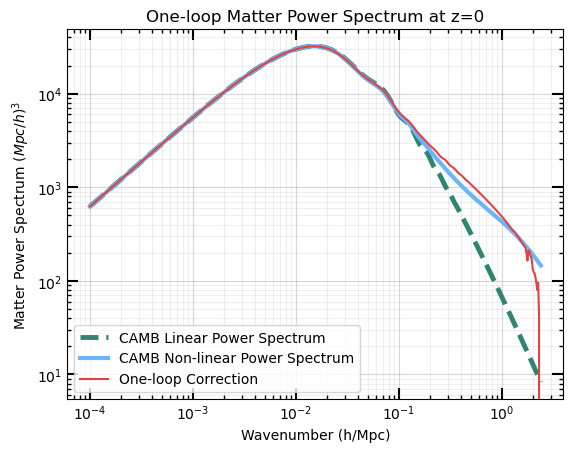

In [5]:
import matplotlib.pyplot as plt


plt.plot(
    k_vals,
    Pk_interp(k_vals),
    label="CAMB Linear Power Spectrum",
    linestyle="--",
    color="#308470",
    linewidth=3.5,
)
plt.plot(
    k_vals,
    P_nonlinear,
    label="CAMB Non-linear Power Spectrum",
    linestyle="-",
    color="#6DB4FB",
    linewidth=3,
)
plt.plot(k_vals, P_one_loop_z0, label="One-loop Correction", color="#E44242FF")

plt.legend()
plt.title("One-loop Matter Power Spectrum at z=0")
plt.grid(True)
plt.xscale("log")
plt.yscale("log")

plt.tick_params(axis="both", direction="in", length=8, width=1.5, top=True, right=True)
plt.tick_params(which="minor", direction="in", length=3, width=1, top=True, right=True)
plt.grid(which="major", alpha=0.5)
plt.grid(which="minor", alpha=0.2)
plt.xlabel("Wavenumber (h/Mpc)")
plt.ylabel("Matter Power Spectrum $(Mpc/h)^3$")

plt.savefig("P_k_redshift.pdf")
plt.show()